## Looking at possible models for predictive the rest of the mirion catalog yellowball physical properties

In [1]:
import pickle
import numpy as np
import pandas as pd
from pyhere import here
import matplotlib.pyplot as plt
from ratio_function import RatioGenerator, LogRatioGenerator
import itertools
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn import set_config
from skopt import BayesSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.svm import SVR
from skopt.space import Categorical, Real, Integer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance

set_config(transform_output="pandas")

## Making Permutation importance plots

In [18]:
phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))

flux_cols = ['F8', 'F12', 'F24', 'F70']

remove_properties = ['LRATIO', 'T_BOL', 'LM', 'L_BOL', 'MASS', 'DIAM', 'SURF_DENS', 'YB', 'TEMP','F160','F250','F350','F500','F870','F1100']

bands = ['8', '12', '24', '70']
for band in bands:
    phot[f'SNR_F{band}'] = phot[f'F{band}'] / phot[f'e_F{band}']

X = phot.drop(columns=remove_properties)

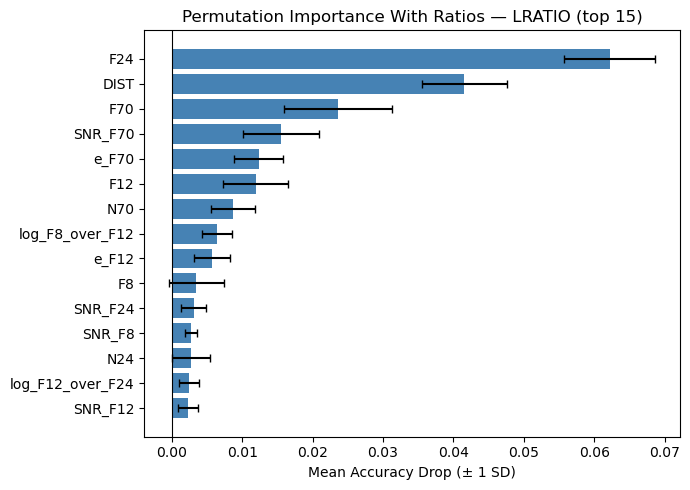

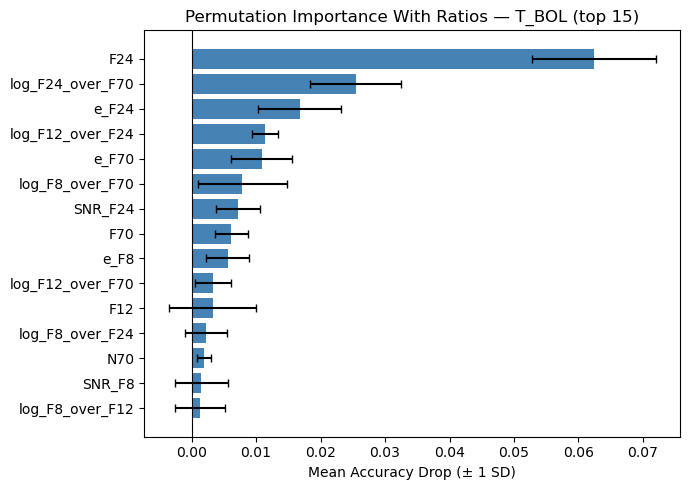

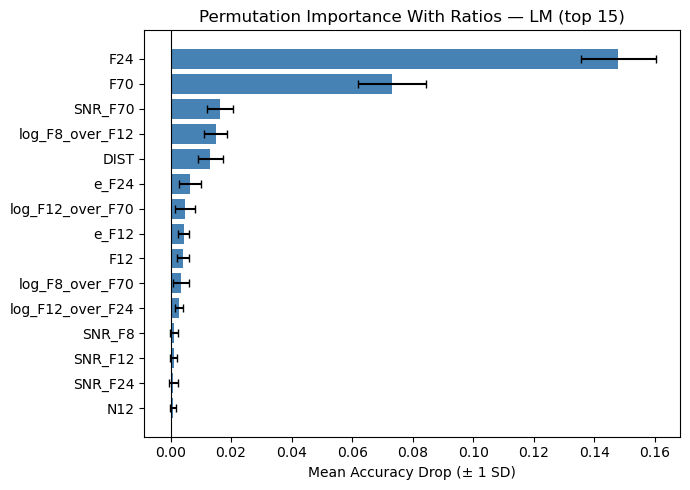

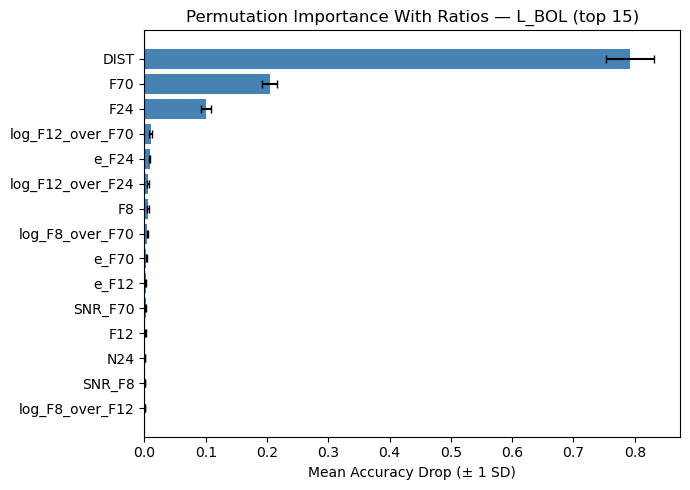

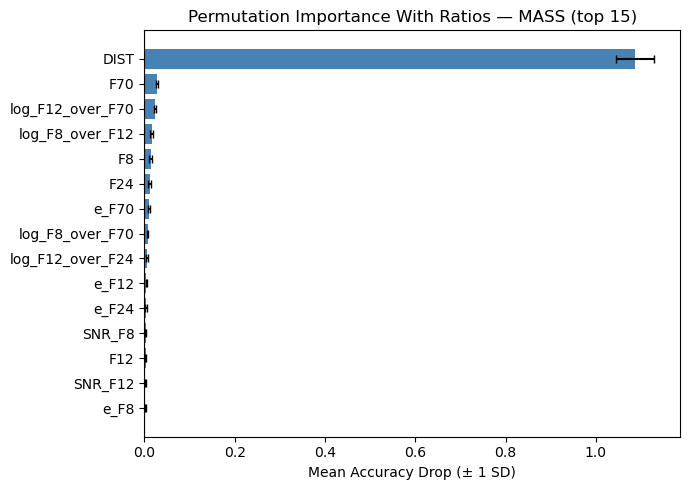

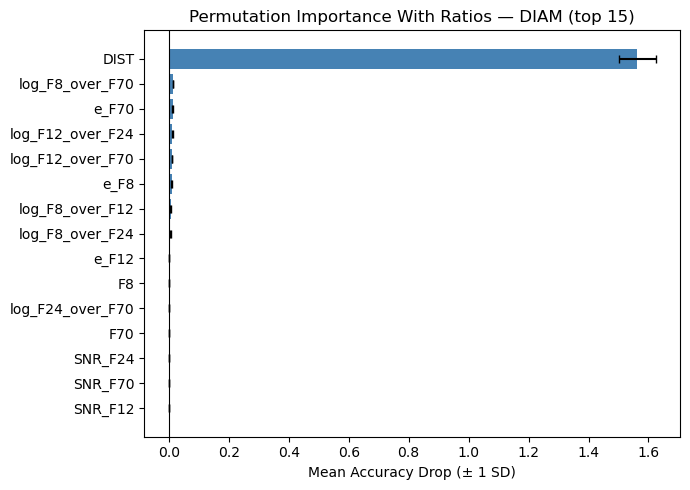

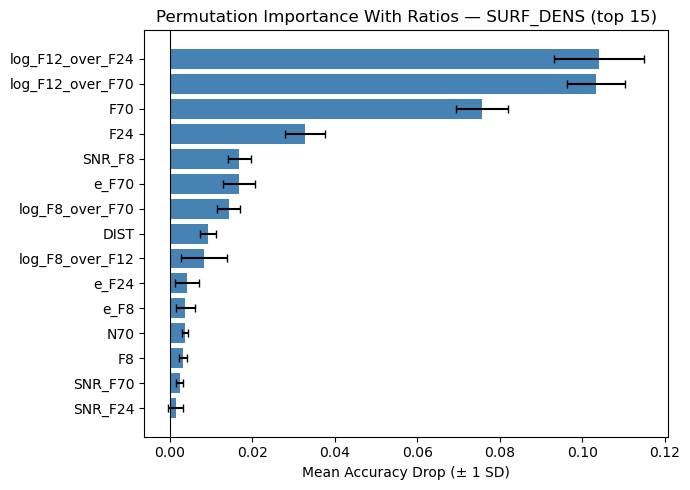

In [21]:
responses = ['LRATIO', 'T_BOL', 'LM', 'L_BOL', 'MASS', 'DIAM', 'SURF_DENS']
for response in responses:
    with open(here("pipeline/results", f"{response}_mirionfluxes_results.pkl"), 'rb') as file:
        results = pickle.load(file)
    if response == 'TEMP' or response == 'T_BOL':
        y = phot[response]
    else:
        y = np.log(phot[response])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2026)

    phot_for_perm = X.copy()
    for top, bottom in itertools.combinations(flux_cols, 2):
        new_col_name = f"log_{top}_over_{bottom}"
        phot_for_perm[new_col_name] = np.log(phot_for_perm[top] / phot_for_perm[bottom])
    X_train, X_test, y_train, y_test = train_test_split(phot_for_perm, y, test_size = 0.2, random_state=2026)
    if response == 'TEMP':
        perm_pipe = Pipeline([
            ('impute', SimpleImputer()),
            ('scale', RobustScaler()),
            ('model', CatBoostRegressor(random_state=2026, verbose=0, thread_count=-1, loss_function='RMSE'))
        ])
        if 'ratio' in results['cat_params']:
            del lbol_results['cat_params']['ratio']
        perm_pipe.set_params(**results['cat_params'])
    else:
        perm_pipe = Pipeline([
            ('impute', SimpleImputer()),
            ('scale', RobustScaler()),
            ('model', XGBRegressor(random_state=2026, verbosity=0, n_jobs=-1))
        ])
        if 'ratio' in results['xgb_params']:
            del results['xgb_params']['ratio']
        perm_pipe.set_params(**results['xgb_params'])
    perm_pipe.fit(X_train, y_train)
    perm_with_ratios = permutation_importance(
        perm_pipe, X_test, y_test,
        n_repeats=10, random_state=2026, n_jobs=-1
    )
    perm_df = (pd.DataFrame({
        'feature': X_test.columns,
        'mean': perm_with_ratios.importances_mean,
        'std':  perm_with_ratios.importances_std
    }).sort_values('mean', ascending=False).head(15))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(perm_df['feature'][::-1], perm_df['mean'][::-1],
            xerr=perm_df['std'][::-1], color='steelblue', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
    ax.set_title(f'Permutation Importance With Ratios — {response} (top 15)')
    plt.tight_layout()
    plt.savefig(here('pipeline/graphing/graphs/perm_imp_graphs/small_models', f'{response}_imp_with_ratios.png'), dpi=300,bbox_inches='tight')
    plt.show()
